In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
# Load dataset
df = pd.read_excel("glass.xlsx",sheet_name="glass")
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


### Exploratory Data Analysis (EDA):

In [3]:
print("Shape:",df.shape)
print(df.info())

Shape: (214, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB
None


In [4]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(1)

In [6]:
df = df.drop_duplicates()
df.shape

(213, 10)

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RI,213.0,1.518348,0.003033,1.51115,1.51652,1.51768,1.51915,1.53393
Na,213.0,13.404085,0.816662,10.73000,12.90000,13.30000,13.81000,17.38000
Mg,213.0,2.679202,1.443691,0.00000,2.09000,3.48000,3.60000,4.49000
Al,213.0,1.449484,0.495925,0.29000,1.19000,1.36000,1.63000,3.50000
Si,213.0,72.655070,0.773998,69.81000,72.28000,72.79000,73.09000,75.41000
K,213.0,0.498873,0.653185,0.00000,0.13000,0.56000,0.61000,6.21000
Ca,213.0,8.954085,1.425882,5.43000,8.24000,8.60000,9.15000,16.19000
Ba,213.0,0.175869,0.498245,0.00000,0.00000,0.00000,0.00000,3.15000
Fe,213.0,0.057277,0.097589,0.00000,0.00000,0.00000,0.10000,0.51000
Type,213.0,2.788732,2.105130,1.00000,1.00000,2.00000,3.00000,7.00000


### Data Visualization:

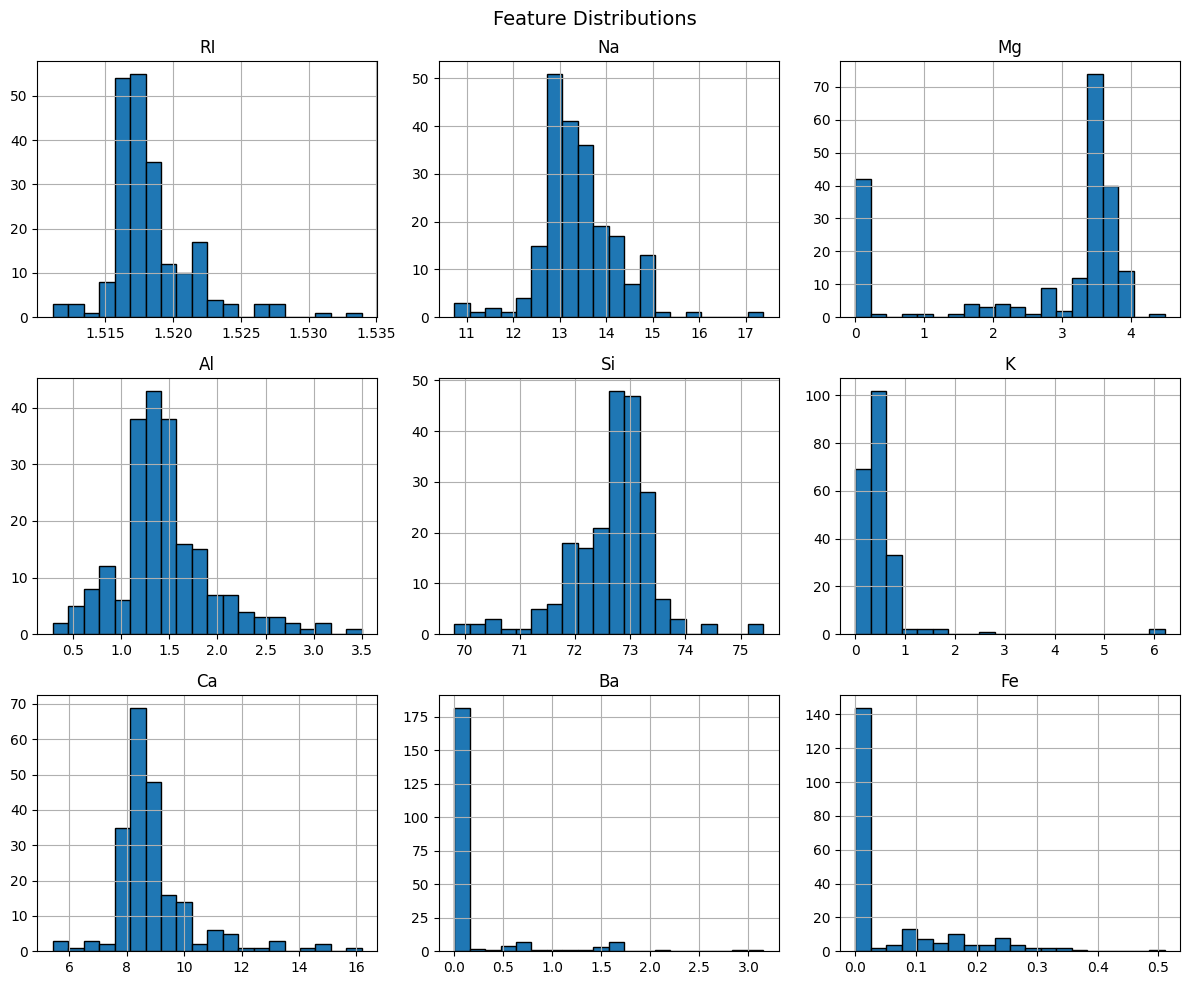

In [8]:
# Histograms for feature distributions (excluding target)
df.drop("Type", axis=1).hist(figsize=(12, 10), bins=20, edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

- Most features show skewed distributions.
- Ba and Fe are highly right-skewed with many near-zero values.
- The features have different ranges, indicating the need for scaling.

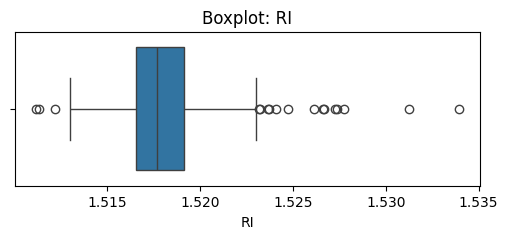

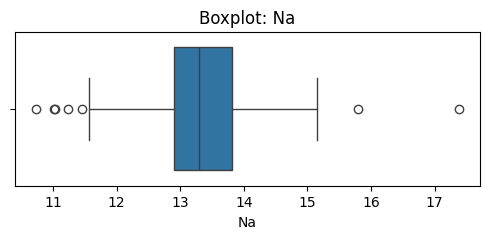

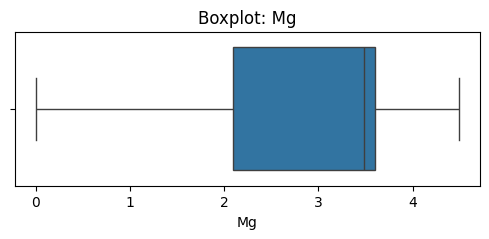

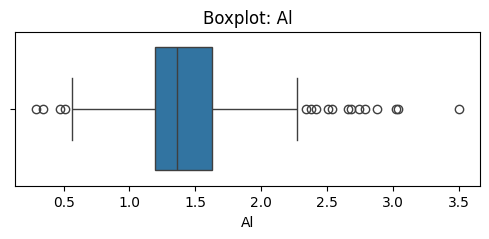

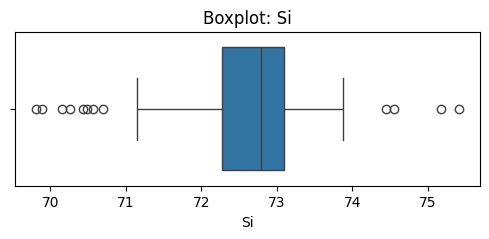

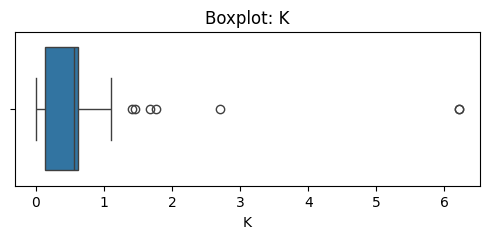

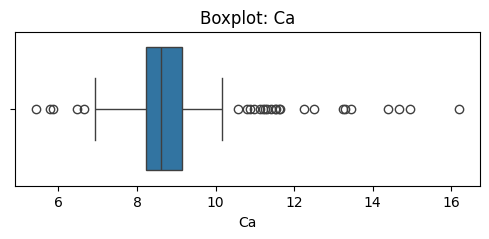

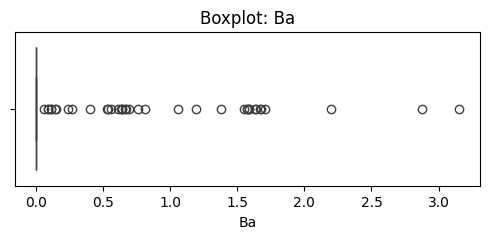

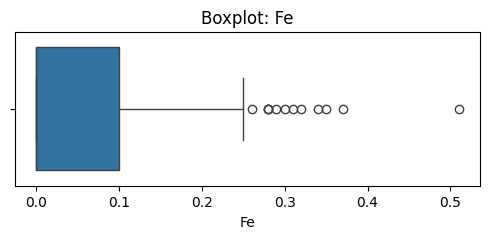

In [9]:
# Boxplots for detecting outliers (excluding target variable)

for col in df.drop("Type", axis=1).columns:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot: {col}")
    plt.show()

The boxplots indicate the presence of outliers in features such as Ca, Ba, and Fe. Most other features show moderate spread with some extreme values.

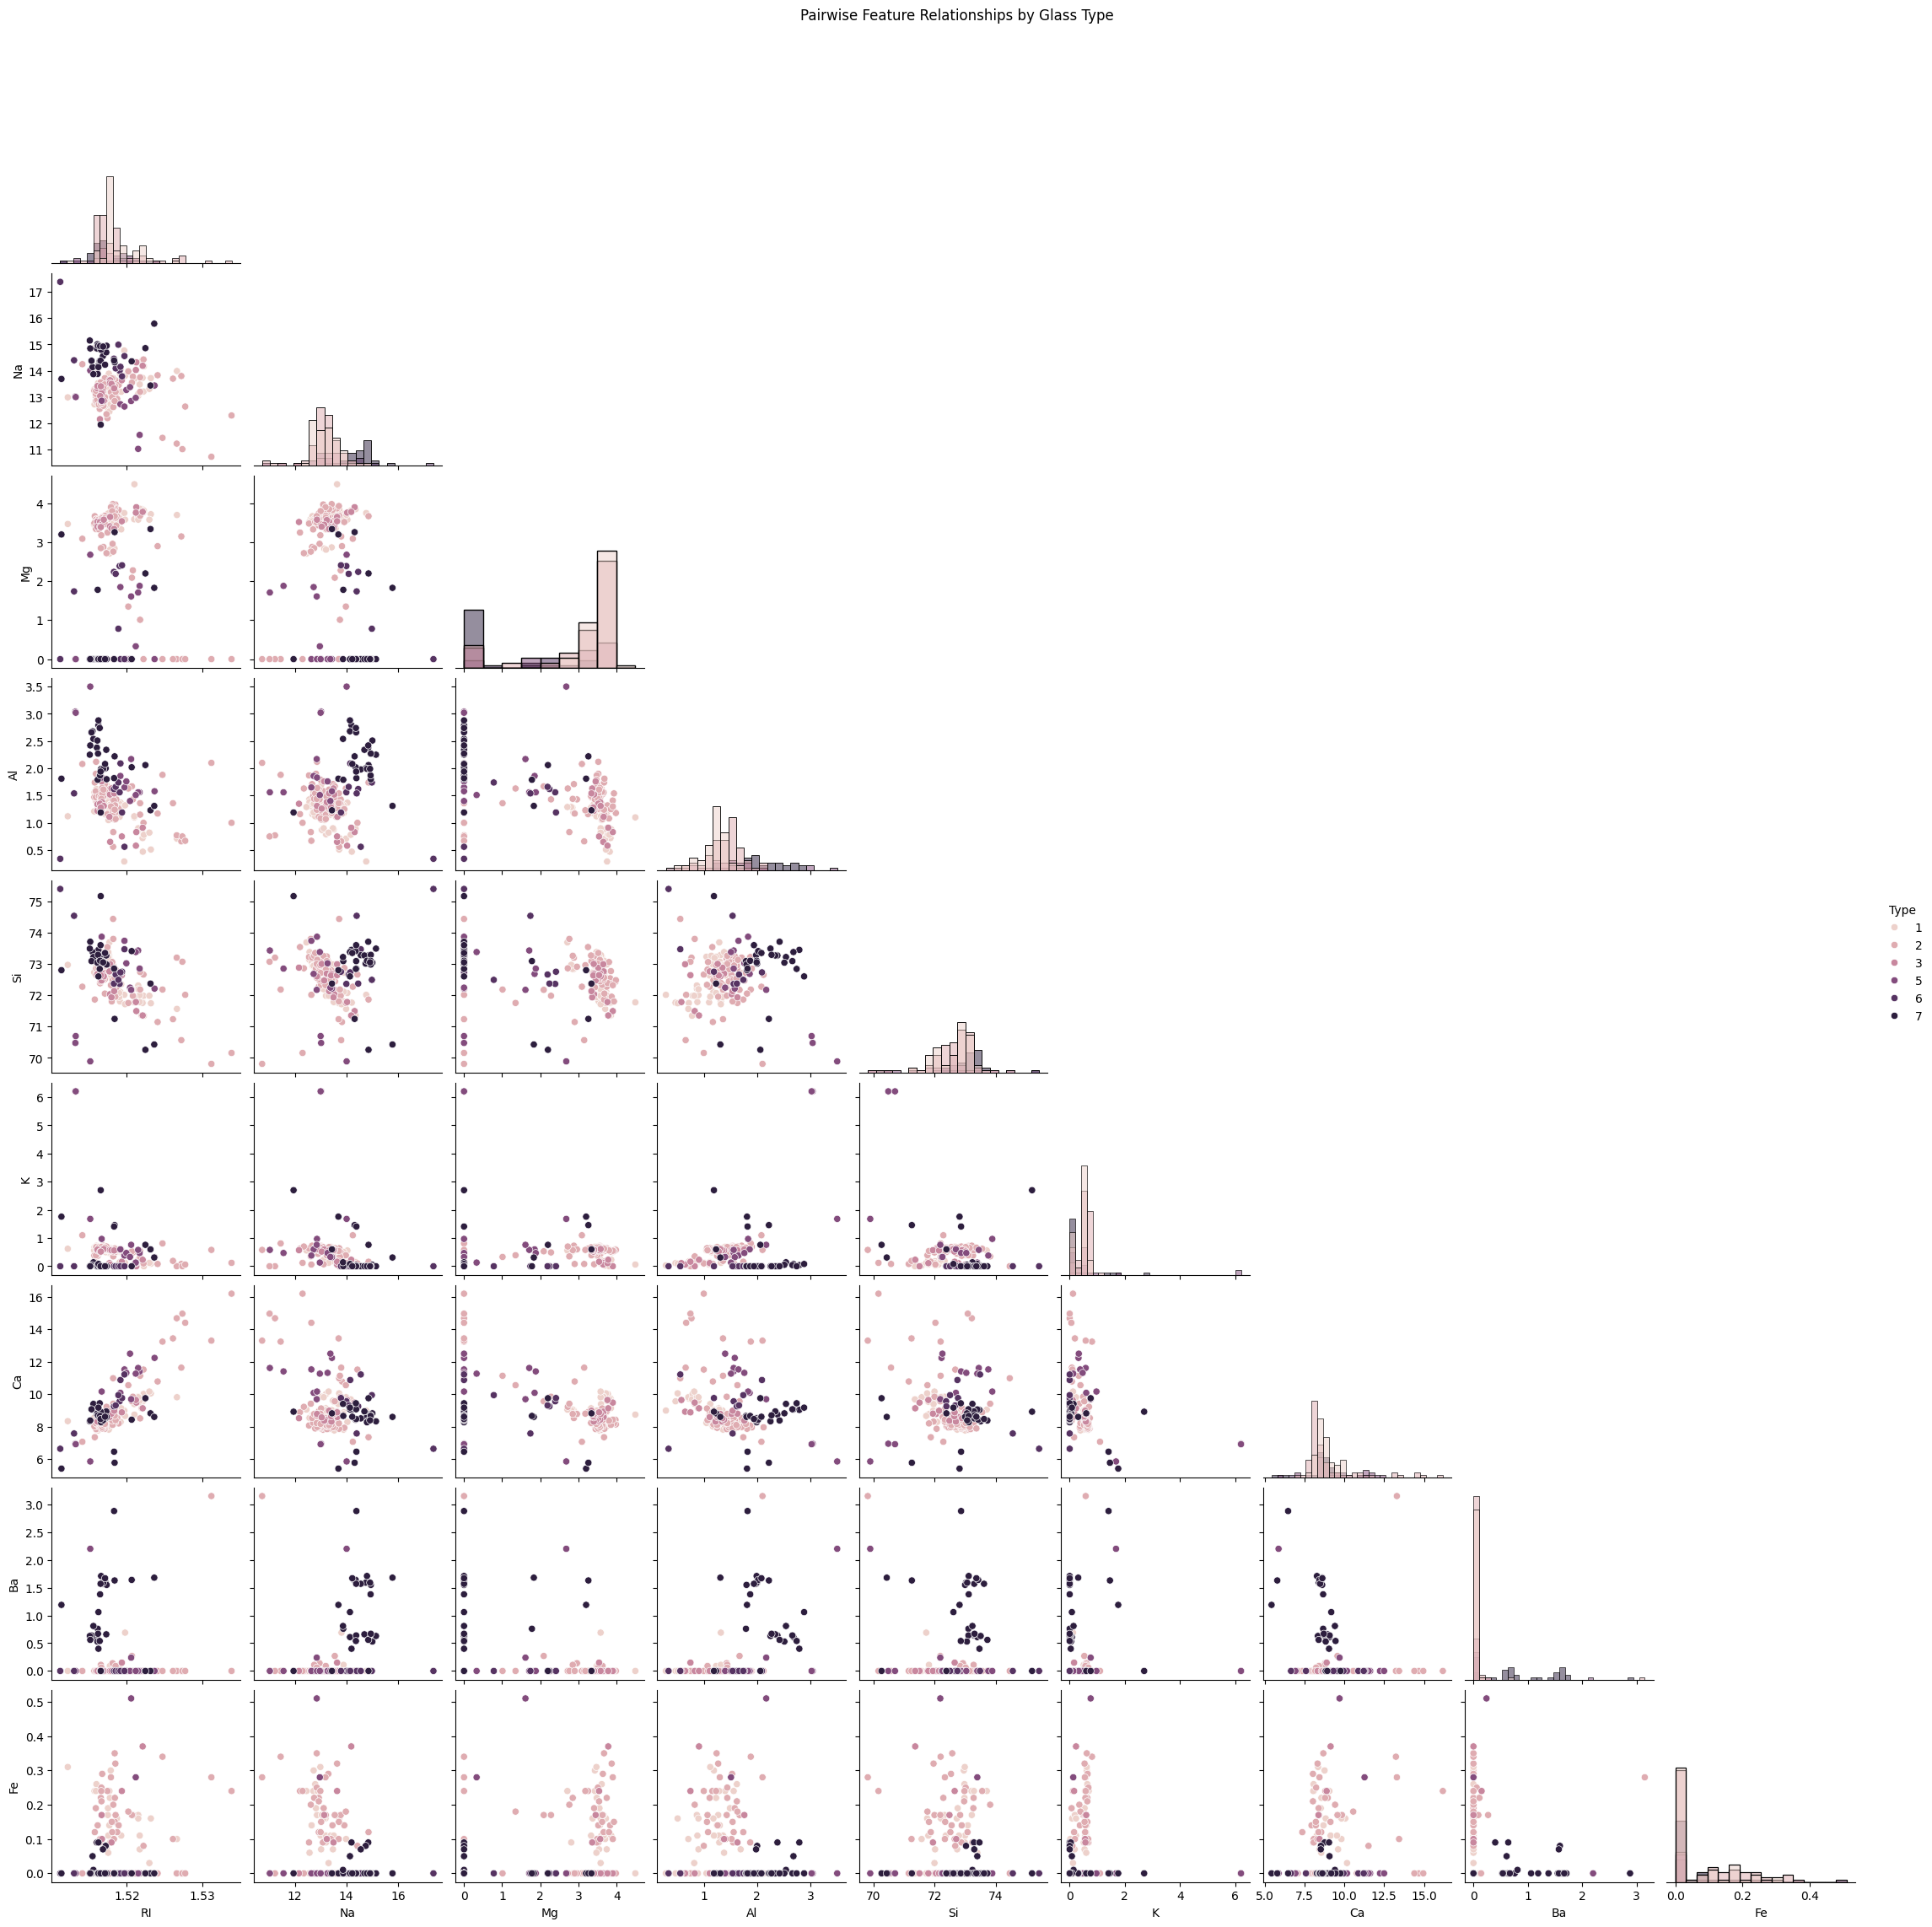

In [10]:
# Pairplot to visualize feature relationships by class

pairplot = sns.pairplot(df, hue="Type", diag_kind="hist", corner=True)
pairplot.fig.suptitle("Pairwise Feature Relationships by Glass Type", y=1.02)

plt.show()

The pairplot shows partial class separation for certain feature combinations, indicating that some variables contribute significantly to distinguishing glass types.

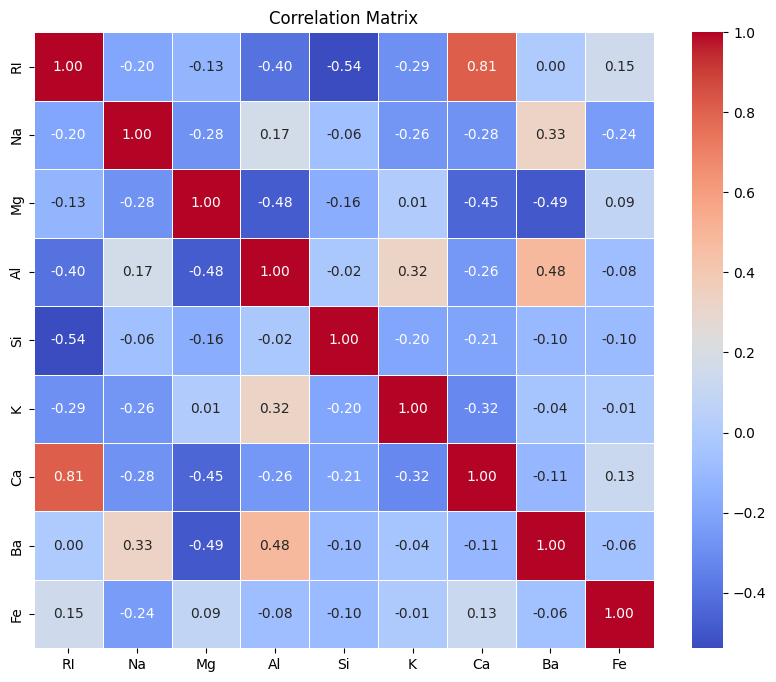

In [11]:
# Correlation matrix (excluding target variable)

plt.figure(figsize=(10, 8))
sns.heatmap(df.drop("Type", axis=1).corr(),annot=True, fmt=".2f", cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

- The correlation matrix shows a strong positive correlation between RI and Ca.
- Some moderate correlations exist (e.g., Al and Ba), while most other features have weak correlations.
- This indicates limited multicollinearity among variables.

### Data Preprocessing

In [12]:
# Check for categorical variables

categorical_cols = df.select_dtypes(include=['object', 'category']).columns

if len(categorical_cols) == 0:
    print("No categorical variables found. Encoding not required.")
else:
    print("Categorical variables detected:", categorical_cols)

No categorical variables found. Encoding not required.


In [13]:
# Separate features and target
X = df.drop("Type", axis=1)
y = df["Type"]

# Train-test split (with stratification for imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling (fit only on training data)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Feature scaling was applied using StandardScaler. The scaler was fitted on training data and applied to test data to prevent data leakage.

### Random Forest Model Implementation

In [14]:
# Now separate Features and target
X = df.drop('Type', axis=1)
y = df['Type']

In [15]:
# Train-Test Split with stratification

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

In [16]:
# Compute class weights using training data
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced',classes=classes,y=y_train)

class_weights = dict(zip(classes, weights))
rf_clf = RandomForestClassifier(n_estimators=100,random_state=42,class_weight=class_weights)

print("Class Weights:", class_weights)

Class Weights: {np.int64(1): np.float64(0.5151515151515151), np.int64(2): np.float64(0.4644808743169399), np.int64(3): np.float64(2.0238095238095237), np.int64(5): np.float64(2.8333333333333335), np.int64(6): np.float64(4.0476190476190474), np.int64(7): np.float64(1.2318840579710144)}


The computed class weights indicate that classes 3, 5, and 6 are underrepresented. Higher weights were assigned to these classes to balance their influence during model training.

In [18]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
rf_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
# Make predictions on test data
y_pred = rf_clf.predict(X_test)

In [21]:
# Evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision (macro):", precision_score(y_test, y_pred, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred, average='macro'))
print("F1-score (macro):", f1_score(y_test, y_pred, average='macro'))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8372093023255814
Precision (macro): 0.8777777777777778
Recall (macro): 0.8595238095238095
F1-score (macro): 0.8561128526645768

Classification Report:
               precision    recall  f1-score   support

           1       0.80      0.86      0.83        14
           2       0.80      0.80      0.80        15
           3       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.84        43
   macro avg       0.88      0.86      0.86        43
weighted avg       0.85      0.84      0.84        43



- The Random Forest model achieved an accuracy of 83.7% with a macro F1-score of 0.856.
- The model performs well across most classes, including minority classes, indicating that class weighting effectively handled imbalance.
- Slight performance variation is observed in classes with very small sample sizes.

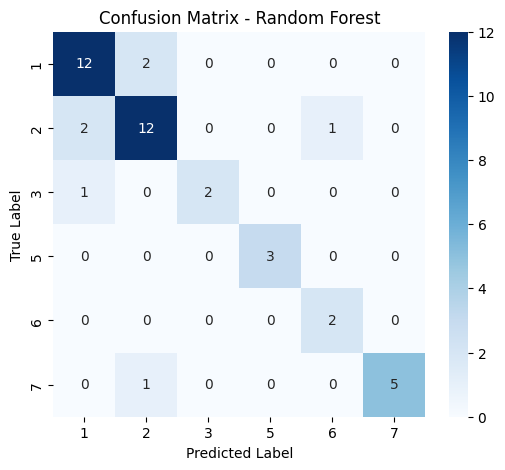

In [23]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",cmap="Blues",xticklabels=np.unique(y),yticklabels=np.unique(y))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

- The confusion matrix indicates that most instances are correctly classified, with errors mainly occurring in minority classes.
- This confirms that the Random Forest model performs well while handling class imbalance effectively.

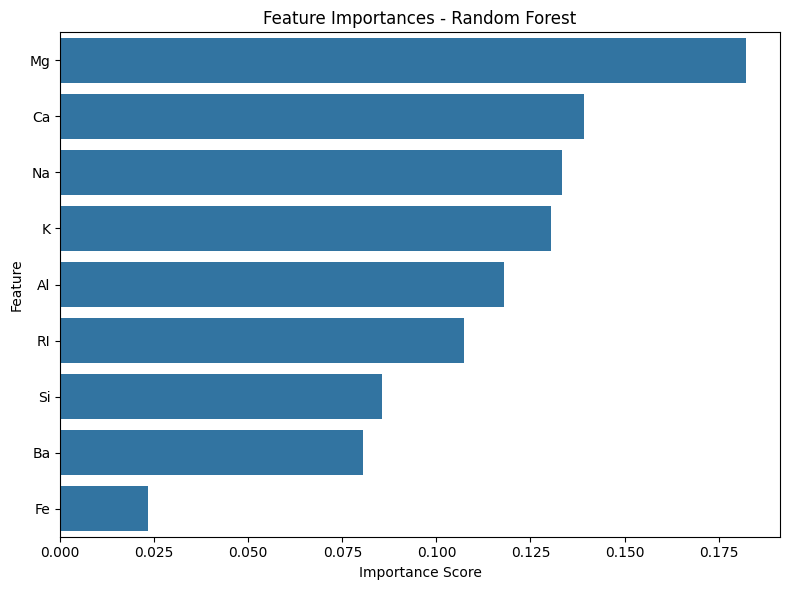

In [25]:
# Feature Importance
importances = rf_clf.feature_importances_

feat_imp_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Plot feature importance
plt.figure(figsize=(8,6))
sns.barplot(x="importance", y="feature", data=feat_imp_df)

plt.title("Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

- The feature importance plot shows that Mg, Ca, and Na are among the most influential features in classifying glass types, while Fe has minimal impact.
- This indicates that certain chemical components play a stronger role in distinguishing between glass categories.

### Bagging and Boosting Methods

In [26]:
# Bagging Classifier using Decision Tree as base estimator

bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)

bag_clf.fit(X_train, y_train)

y_pred_bag = bag_clf.predict(X_test)

print("\nBagging Results")
print("Accuracy:", accuracy_score(y_test, y_pred_bag))
print("Precision (macro):", precision_score(y_test, y_pred_bag, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred_bag, average='macro'))
print("F1-score (macro):", f1_score(y_test, y_pred_bag, average='macro'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_bag))


Bagging Results
Accuracy: 0.7674418604651163
Precision (macro): 0.7353479853479853
Recall (macro): 0.7968253968253968
F1-score (macro): 0.7592952811343615

Classification Report:

              precision    recall  f1-score   support

           1       0.77      0.71      0.74        14
           2       0.79      0.73      0.76        15
           3       0.67      0.67      0.67         3
           5       0.67      0.67      0.67         3
           6       0.67      1.00      0.80         2
           7       0.86      1.00      0.92         6

    accuracy                           0.77        43
   macro avg       0.74      0.80      0.76        43
weighted avg       0.77      0.77      0.76        43



- The Bagging classifier achieved an accuracy of 76.7% with a macro F1-score of 0.76. While it improves prediction stability compared to a single decision tree, its performance is lower than Random Forest.
- This indicates that Random Forest’s additional feature randomness enhances classification performance.

In [27]:
# Boosting (AdaBoost)
boost_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=50,
    random_state=42
)
boost_clf.fit(X_train, y_train)
y_pred_boost = boost_clf.predict(X_test)

print("\nBoosting (AdaBoost) Results")
print("Accuracy:", accuracy_score(y_test, y_pred_boost))
print(classification_report(y_test, y_pred_boost, zero_division=0))


Boosting (AdaBoost) Results
Accuracy: 0.813953488372093
              precision    recall  f1-score   support

           1       0.92      0.79      0.85        14
           2       0.76      0.87      0.81        15
           3       0.50      0.67      0.57         3
           5       1.00      0.67      0.80         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.81        43
   macro avg       0.81      0.80      0.79        43
weighted avg       0.84      0.81      0.82        43



AdaBoost was implemented using shallow Decision Trees as base learners.Boosting works by sequentially focusing on previously misclassified samples, improving overall model performance.

- Among the three ensemble methods, Random Forest achieved the highest performance with an accuracy of 83.7% and macro F1-score of 0.856.
- AdaBoost performed slightly lower with 81.4% accuracy, while Bagging achieved 76.7%. The results indicate that Random Forest provides better generalization due to its combination of bagging and feature randomness.
- Therefore, Random Forest is the most effective model for this dataset.

#### Conclusion

- In this study, ensemble learning techniques were applied to classify glass types.
- Data preprocessing, feature scaling, and class imbalance handling were performed to improve model performance. Among the models tested, Random Forest achieved the highest accuracy and macro F1-score, demonstrating superior performance compared to Bagging and AdaBoost.
- The results show that ensemble methods, especially Random Forest, are highly effective for multi-class classification problems with imbalanced data.

#### Additional Notes:

**1. Explain Bagging and Boosting methods. How is it different from each other.**

- Bagging (Bootstrap Aggregating) is an ensemble method where multiple models are trained independently on different bootstrap samples of the data, and their predictions are combined (usually by majority voting). It mainly reduces variance and helps prevent overfitting. Example: Random Forest.

- Boosting is an ensemble method where models are trained sequentially, and each new model focuses more on correcting the mistakes of the previous ones. It mainly reduces bias and improves accuracy. Example: AdaBoost.

- Difference: Bagging trains models in parallel and reduces variance, while boosting trains models sequentially and reduces bias by focusing on errors.

**2. Explain how to handle imbalance in the data.**

- Imbalanced data occurs when some classes have significantly fewer samples than others.This can cause the model to become biased toward majority classes.
- To handle imbalance, techniques such as resampling (oversampling minority classes or undersampling majority classes), using class weights, or applying specialized algorithms can be used.
- In this project, class weights were applied so that minority classes received higher importance during model training, improving overall balanced performance.